# Figure 4, Part 2: Decision variable prediction

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env.py
%run run.py connect

2025-02-12 13:33:35,854::INFO::settings.py::Setting loglevel to INFO
2025-02-12 13:33:35,856::INFO::settings.py::Setting stores to {}
2025-02-12 13:33:35,856::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-02-12 13:33:35,857::INFO::settings.py::Setting database.misc.create_tables to True
2025-02-12 13:33:35,857::INFO::settings.py::Setting enable_python_native_blobs to True
2025-02-12 13:33:35,858::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2025-02-12 13:33:35,859::INFO::settings.py::Setting database.user to celia
2025-02-12 13:33:35,860::INFO::settings.py::Setting database.password to celia
2025-02-12 13:33:35,917::INFO::connection.py::Connected celia@128.178.51.167:3309
2025-02-12 13:33:35,926::INFO::table.py::could not log event in table ~log


Connecting celia@128.178.51.167:3309


2025-02-12 13:33:36,600::INFO::table.py::could not log event in table ~log
2025-02-12 13:33:36,600::INFO::table.py::could not log event in table ~log
2025-02-12 13:33:36,612::INFO::table.py::could not log event in table ~log
2025-02-12 13:33:36,612::INFO::table.py::could not log event in table ~log
2025-02-12 13:33:36,638::INFO::table.py::could not log event in table ~log
2025-02-12 13:33:36,638::INFO::table.py::could not log event in table ~log
2025-02-12 13:33:36,661::INFO::table.py::could not log event in table ~log
2025-02-12 13:33:36,661::INFO::table.py::could not log event in table ~log


In [26]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils
from vr4mice.analysis import regression

from statsmodels.stats.anova import AnovaRM 
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats
style()

save_fig_path =  "notebooks/Paper_figures/Figure_output/"

In [5]:
# See Figure 4 B-E notebook to see how the data was generated
big_df = pd.read_pickle("big_df_contrast_multi.pkl")

In [6]:
big_df = big_df [big_df.iti ==0.0]
#big_df = big_df [big_df.trial_rewarded == 1.0]
# only rewarded trials doesn't make sense if we keep trial_rewarded as a feature in the model

In [9]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})
interpolated_j_shaped = utils.interpolate_j_shaped(big_df, box_df, n_points=500)

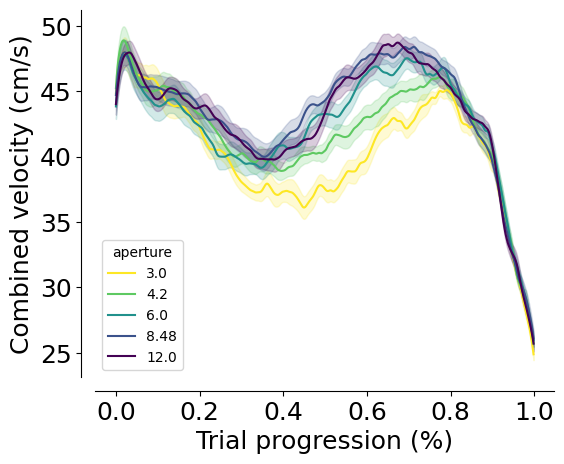

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax = ax
mean_mouse = interpolated_j_shaped.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

label = "velocity"
sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y="velocity",
        palette=plotting.colors_multi_aperture,
        hue="aperture",
        errorbar="se",
        ax=ax,
    )

sns.despine(offset=10)
ax.set_xlabel("Trial progression (%)")
ax.set_ylabel("Combined velocity (cm/s)")
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "multi_occluder_velocity.svg", transparent=False)

In [21]:
counts

,index,mouse_name,dataset,aperture,optimal_p,count
0,0,Jacana,Jacana_2024-08-20_1,3.0,22.562139,22.562139
1,1,Jacana,Jacana_2024-08-20_1,4.2,16.277172,16.277172
2,2,Jacana,Jacana_2024-08-20_1,6.0,16.631102,16.631102
3,3,Jacana,Jacana_2024-08-20_1,8.48,18.914328,18.914328
4,4,Jacana,Jacana_2024-08-20_1,12.0,13.066171,13.066171
...,...,...,...,...,...,...
110,110,Pheasant,Pheasant_2024-08-28_1,3.0,11.451737,11.451737
111,111,Pheasant,Pheasant_2024-08-28_1,4.2,12.868421,12.868421
112,112,Pheasant,Pheasant_2024-08-28_1,6.0,17.206596,17.206596
113,113,Pheasant,Pheasant_2024-08-28_1,8.48,14.228647,14.228647


2025-02-12 14:00:43,783::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 14:00:43,783::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 14:00:43,796::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 14:00:43,796::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 14:00:43,873::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=0.860767944956394, pvalue=0.39865005473971116, df=22)
3.0-6.0: TtestResult(statistic=0.9683091080596103, pvalue=0.3434155271872986, df=22)
3.0-8.48: TtestResult(statistic=2.124796259385194, pvalue=0.04507842112148481, df=22)
4.2-6.0: TtestResult(statistic=0.4715593133411037, pvalue=0.6418844506264607, df=22)
4.2-8.48: TtestResult(statistic=1.4569765168858826, pvalue=0.15924898165332702, df=22)
6.0-8.48: TtestResult(statistic=0.8873377978054334, pvalue=0.3844952857449486, df=22)
12.0-3.0: TtestResult(statistic=-2.3329689077889184, pvalue=0.029194767776094366, df=22)
12.0-4.2: TtestResult(statistic=-2.07034906949888, pvalue=0.050357783018695514, df=22)
12.0-6.0: TtestResult(statistic=-2.25810332571236, pvalue=0.034197327259382314, df=22)
12.0-8.48: TtestResult(statistic=-0.7205126630701593, pvalue=0.47879592095716117, df=22)


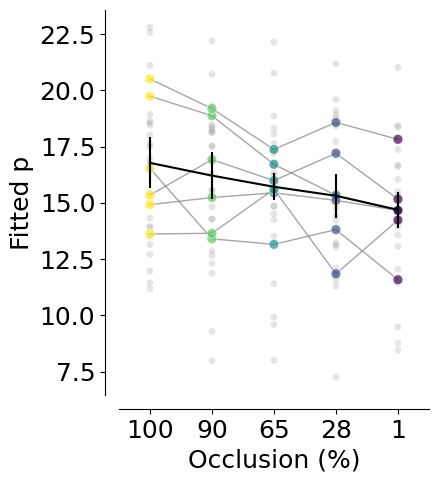

In [28]:
# fitted p of the optimal L-p curve

big_df["optimal_p"] = analysis.get_optimal_p(big_df)
j_shaped = analysis.get_jshaped_trials(big_df)


fig,ax = plt.subplots(1,1, figsize = (4,5))

counts = j_shaped[j_shaped.trial_rewarded==1].groupby(["mouse_name", "dataset", "aperture"], as_index=False).optimal_p.mean()

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_multi_aperture,
)
ax.invert_xaxis()

ax.set_xlabel("Occlusion (%)")
ax.set_ylabel("Fitted p")
ax.set_xlim(-.5,4.5)
ax.set_xticks([0,1,2,3,4], ["100", "90", "65", "28", "1"])
plt.legend([],[], frameon=False)
sns.despine(offset=10)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["optimal_p"],
                counts[counts["aperture"] == j]["optimal_p"],
            )
            print(f"{i}-{j}: {stat}")

In [11]:
interpolated_j_shaped["aperture"] = interpolated_j_shaped["aperture"].astype(float)

df_model, coef = regression.predict_decision(
    df=interpolated_j_shaped, label=regression.model_labels, per_mouse=True)

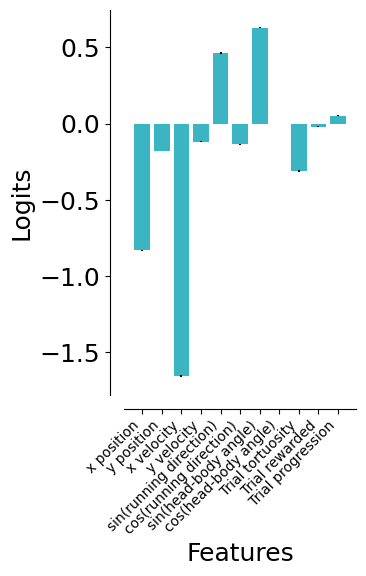

In [12]:
# Logits of the regression
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
ax.bar(
    regression.model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=stats.sem(coef[:, 1:], axis=0),
    color="#3AB5C1"
)
sns.despine(offset=10, ax=ax)

ax.set_xticks(np.arange(len(regression.model_labels))) 
ax.set_xticklabels(regression.clean_model_labels, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Logits")
ax.set_xlabel("Features")

plt.savefig(save_fig_path + "multi_occluder_model_logits.svg", transparent=False)

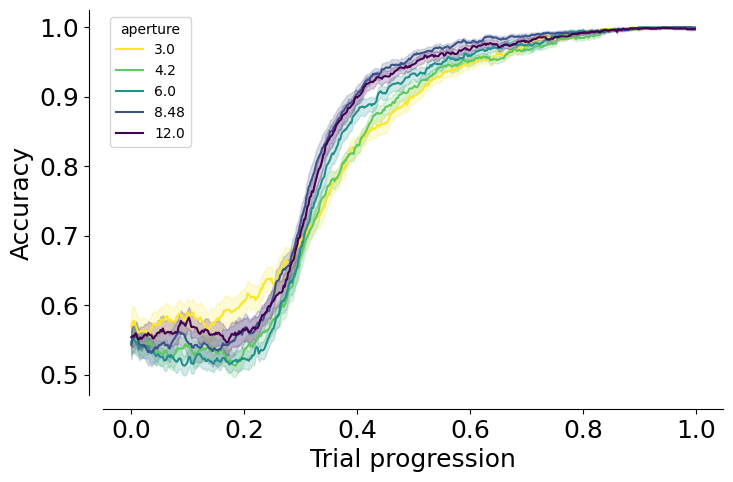

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

mean_mouse = df_model.groupby(["dataset", "aperture", "trial_length"]).mean(
    numeric_only=True
)

mean_mouse_per_choice = df_model.groupby(
    ["dataset", "trial_left_choice", "aperture", "trial_length"]
).mean(numeric_only=True)

# Accuracy
sns.lineplot(
    ax=ax,
    data=mean_mouse,
    y="accuracy",
    x="trial_length",
    hue="aperture",
    palette=plotting.colors_multi_aperture,
    errorbar="se",
)
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Accuracy")
#percentile = np.percentile(mean_mouse_model_shuff.accuracy, 95)
plt.savefig(save_fig_path + "multi_occluder_model_accuracy.svg", transparent=False)


In [14]:
df_model ["session"] = df_model ["dataset"]
df_model ["trial_L_choice"] = df_model ["trial_left_choice"]
decision_points = regression.find_decision_point(df_model, threshold_uncertainty=0.3)

2025-02-12 13:38:07,084::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 13:38:07,084::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 13:38:07,092::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 13:38:07,092::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 13:38:07,171::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=1.8963497917014327, pvalue=0.07112278638741246, df=22)
3.0-6.0: TtestResult(statistic=3.9112356533018215, pvalue=0.0007487019032070464, df=22)
3.0-8.48: TtestResult(statistic=7.748659890854545, pvalue=9.987078488930148e-08, df=22)
4.2-6.0: TtestResult(statistic=3.725321164340134, pvalue=0.001175771692940183, df=22)
4.2-8.48: TtestResult(statistic=6.627416557572479, pvalue=1.1549646232885545e-06, df=22)
6.0-8.48: TtestResult(statistic=4.740369780269723, pvalue=9.897154613617574e-05, df=22)
12.0-3.0: TtestResult(statistic=-8.650077997312827, pvalue=1.575543582472075e-08, df=22)
12.0-4.2: TtestResult(statistic=-9.060169164498582, pvalue=7.045757185211569e-09, df=22)
12.0-6.0: TtestResult(statistic=-7.592184878841795, pvalue=1.3914082447755655e-07, df=22)
12.0-8.48: TtestResult(statistic=-1.9298260402532363, pvalue=0.06662273203818041, df=22)


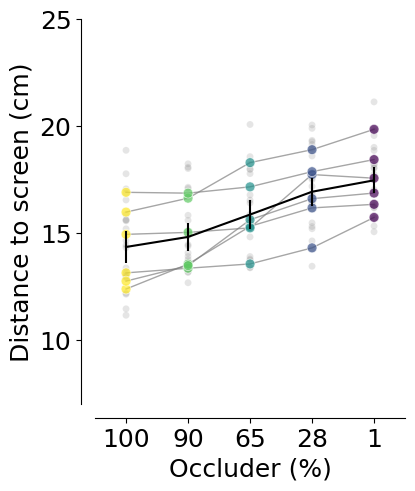

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
_ = plotting.pairplot_average_decision_point(decision_points, 
                                                 label_parameter="y",  
                                                 ax=ax, 
                                                 cmap=plotting.colors_multi_aperture,
                                                 per_mouse=True)
ax.set_ylim(7,25)
ax.set_xlim(-.5,4.5)
ax.set_xticks([0,1,2,3,4], ["100", "90", "65", "28", "1"])
plt.legend([],[], frameon=False)
sns.despine(offset=10)

plt.savefig(save_fig_path + "multi_occluder_decision_points.svg", transparent=True)

In [16]:
decision_points = decision_points.groupby(["dataset", "aperture"], as_index=False)["y"].mean()
anova_rm = AnovaRM(decision_points, depvar='y', subject='dataset', within=['aperture'])

anova_results = anova_rm.fit()
anova_table = anova_results.summary()
print(anova_table)

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture 41.1619 4.0000 88.0000 0.0000



In [17]:
trials_by_time = interpolated_j_shaped.groupby(["aperture", "trial_step", "trial_left_choice"], as_index=False)[["x", "y"]].mean()

<Axes: xlabel='x', ylabel='y'>

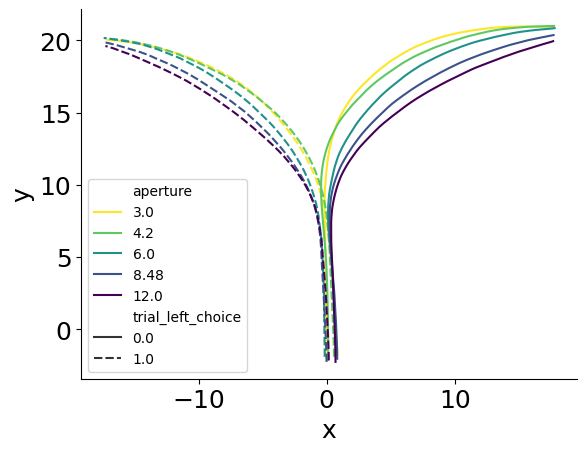

In [18]:
sns.lineplot(trials_by_time, 
             x="x", 
             y="y", 
             hue="aperture", 
             style="trial_left_choice", 
             palette=plotting.colors_multi_aperture, 
             sort=False, 
             alpha=1)